In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

# Set the maximum number of rows and columns to display
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

%matplotlib inline

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv


# Exploring Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv')

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## Data Description

| Column | Description |
| --- | --- |
| Date | Date |
| Location | Name of the city from Australia. |
| MinTemp | The Minimum temperature during a particular day. (degree Celsius) |
| MaxTemp | The maximum temperature during a particular day. (degree Celsius) |
| Rainfall | Rainfall during a particular day. (millimeters) |
| Evaporation | Evaporation during a particular day. (millimeters) |
| Sunshine | Bright sunshine during a particular day. (hours) |
| WindGusDir | The direction of the strongest gust during a particular day. (16 compass points) |
| WindGuSpeed | Speed of strongest gust during a particular day. (kilometers per hour) |
| WindDir9am | The direction of the wind for 10 min prior to 9 am. (compass points) |
| WindDir3pm | The direction of the wind for 10 min prior to 3 pm. (compass points) |
| WindSpeed9am | Speed of the wind for 10 min prior to 9 am. (kilometers per hour) |
| WindSpeed3pm | Speed of the wind for 10 min prior to 3 pm. (kilometers per hour) |
| Humidity9am | The humidity of the wind at 9 am. (percent) |
| Humidity3pm | The humidity of the wind at 3 pm. (percent) |
| Pressure9am | Atmospheric pressure at 9 am. (hectopascals) |
| Pressure3pm | Atmospheric pressure at 3 pm. (hectopascals) |
| Cloud9am | Cloud-obscured portions of the sky at 9 am. (eighths) |
| Cloud3pm | Cloud-obscured portions of the sky at 3 pm. (eighths) |
| Temp9am | The temperature at 9 am. (degree Celsius) |
| Temp3pm | The temperature at 3 pm. (degree Celsius) |
| RainToday | If today is rainy then ‘Yes’. If today is not rainy then ‘No’. |
| RainTomorrow | If tomorrow is rainy then 1 (Yes). If tomorrow is not rainy then 0 (No). |

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


## Dataset Overview
The dataset contains 142,193 observations and 24 features.

Feature Types

17 Numerical features
7 Categorical features
Target variable: RainTomorrow

In [7]:
# column Date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

## Handling Missing Values

### Percentage Missing

In [8]:

pd.DataFrame(df.isnull().mean().round(6).mul(100).sort_values(ascending=False), columns=['Percentage Missing'])

,Percentage Missing
Sunshine,48.0098
Evaporation,43.1665
Cloud3pm,40.8071
Cloud9am,38.4216
Pressure9am,10.3568
Pressure3pm,10.3314
WindDir9am,7.2639
WindGustDir,7.0989
WindGustSpeed,7.0555
Humidity3pm,3.0984


In [9]:
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [10]:
df[categorical_cols].nunique()

Location        49
WindGustDir     16
WindDir9am      16
WindDir3pm      16
RainToday        2
RainTomorrow     2
dtype: int64

In [11]:
# Duplicate entries
df.duplicated().sum()

np.int64(0)

In [12]:
quantitative_vars = df.select_dtypes(include=['float64'])

stats_summary = quantitative_vars.describe()

print(stats_summary)

             MinTemp        MaxTemp       Rainfall   Evaporation  \
count  143975.000000  144199.000000  142199.000000  82670.000000   
mean       12.194034      23.221348       2.360918      5.468232   
std         6.398495       7.119049       8.478060      4.193704   
min        -8.500000      -4.800000       0.000000      0.000000   
25%         7.600000      17.900000       0.000000      2.600000   
50%        12.000000      22.600000       0.000000      4.800000   
75%        16.900000      28.200000       0.800000      7.400000   
max        33.900000      48.100000     371.000000    145.000000   

           Sunshine  WindGustSpeed   WindSpeed9am   WindSpeed3pm  \
count  75625.000000  135197.000000  143693.000000  142398.000000   
mean       7.611178      40.035230      14.043426      18.662657   
std        3.785483      13.607062       8.915375       8.809800   
min        0.000000       6.000000       0.000000       0.000000   
25%        4.800000      31.000000       7.0000

### Delete columns

In [13]:
# Set a threshold. If exceeds this threshold, the column will be removed
threshold = 0.3

# Calculate the proportion of missing values for each column
missing_ratio = df.isnull().sum() / len(df)

# Retain only the columns where the proportion of missing values is below the defined threshold
df = df[missing_ratio[missing_ratio < threshold].index]

# delete the missing rows for RainToday and RainTomorrow
df.dropna(axis=0, subset=['RainToday', 'RainTomorrow'], inplace=True)

numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140787 entries, 0 to 145458
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           140787 non-null  datetime64[ns]
 1   Location       140787 non-null  object        
 2   MinTemp        140319 non-null  float64       
 3   MaxTemp        140480 non-null  float64       
 4   Rainfall       140787 non-null  float64       
 5   WindGustDir    131624 non-null  object        
 6   WindGustSpeed  131682 non-null  float64       
 7   WindDir9am     131127 non-null  object        
 8   WindDir3pm     137117 non-null  object        
 9   WindSpeed9am   139732 non-null  float64       
 10  WindSpeed3pm   138256 non-null  float64       
 11  Humidity9am    139270 non-null  float64       
 12  Humidity3pm    137286 non-null  float64       
 13  Pressure9am    127044 non-null  float64       
 14  Pressure3pm    127018 non-null  float64       
 15  Temp9

### Fill missing rows with median or mode

In [15]:
print(df.groupby('Location')[numeric_cols].median().to_string())

for col in numeric_cols:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.median()))
    df[col].fillna(df[col].median(), inplace=True)

                  MinTemp  MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Temp9am  Temp3pm
Location                                                                                                                                                     
Adelaide             12.1    21.80       0.0           35.0           9.0          15.0         60.0         44.0      1018.70      1016.80     16.2    20.50
Albany               12.9    20.00       0.0            NaN           9.0          19.0         75.0         67.0      1018.50      1016.60     16.3    18.50
Albury                9.1    21.90       0.0           31.0           7.0          13.0         76.0         47.0      1018.40      1015.60     14.1    20.50
AliceSprings         13.6    29.90       0.0           39.0          15.0          17.0         36.0         19.0      1016.70      1012.70     21.9    28.50
BadgerysCreek        11.4    23.20       0.0        

In [16]:
modes_by_loc = df.groupby('Location')[['WindGustDir', 'WindDir9am', 'WindDir3pm']].agg(
    lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else None
)

print(modes_by_loc.to_string())

categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
for col in categorical_cols:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))
    df[col].fillna(df[col].mode()[0], inplace=True)

                 WindGustDir WindDir9am WindDir3pm
Location                                          
Adelaide                 WSW        NNE        WSW
Albany                  None         NW        ESE
Albury                     W         SE          W
AliceSprings             ESE        ESE        ESE
BadgerysCreek             SW         SW        NNE
Ballarat                   N          N          N
Bendigo                  SSE        SSE          N
Brisbane                   E         SW        ENE
Cairns                    SE        SSE         SE
Canberra                  NW        NNW         NW
Cobar                     SW         NE         SW
CoffsHarbour              NE         SW         NE
Dartmoor                 SSW          N        SSW
Darwin                     E         SE        WNW
GoldCoast                SSE        SSE         SE
Hobart                   NNW        NNW         SE
Katherine                  E         SE        ESE
Launceston               NNW   

### Check null values 

In [17]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
Month            0
dtype: int64

## DataViz

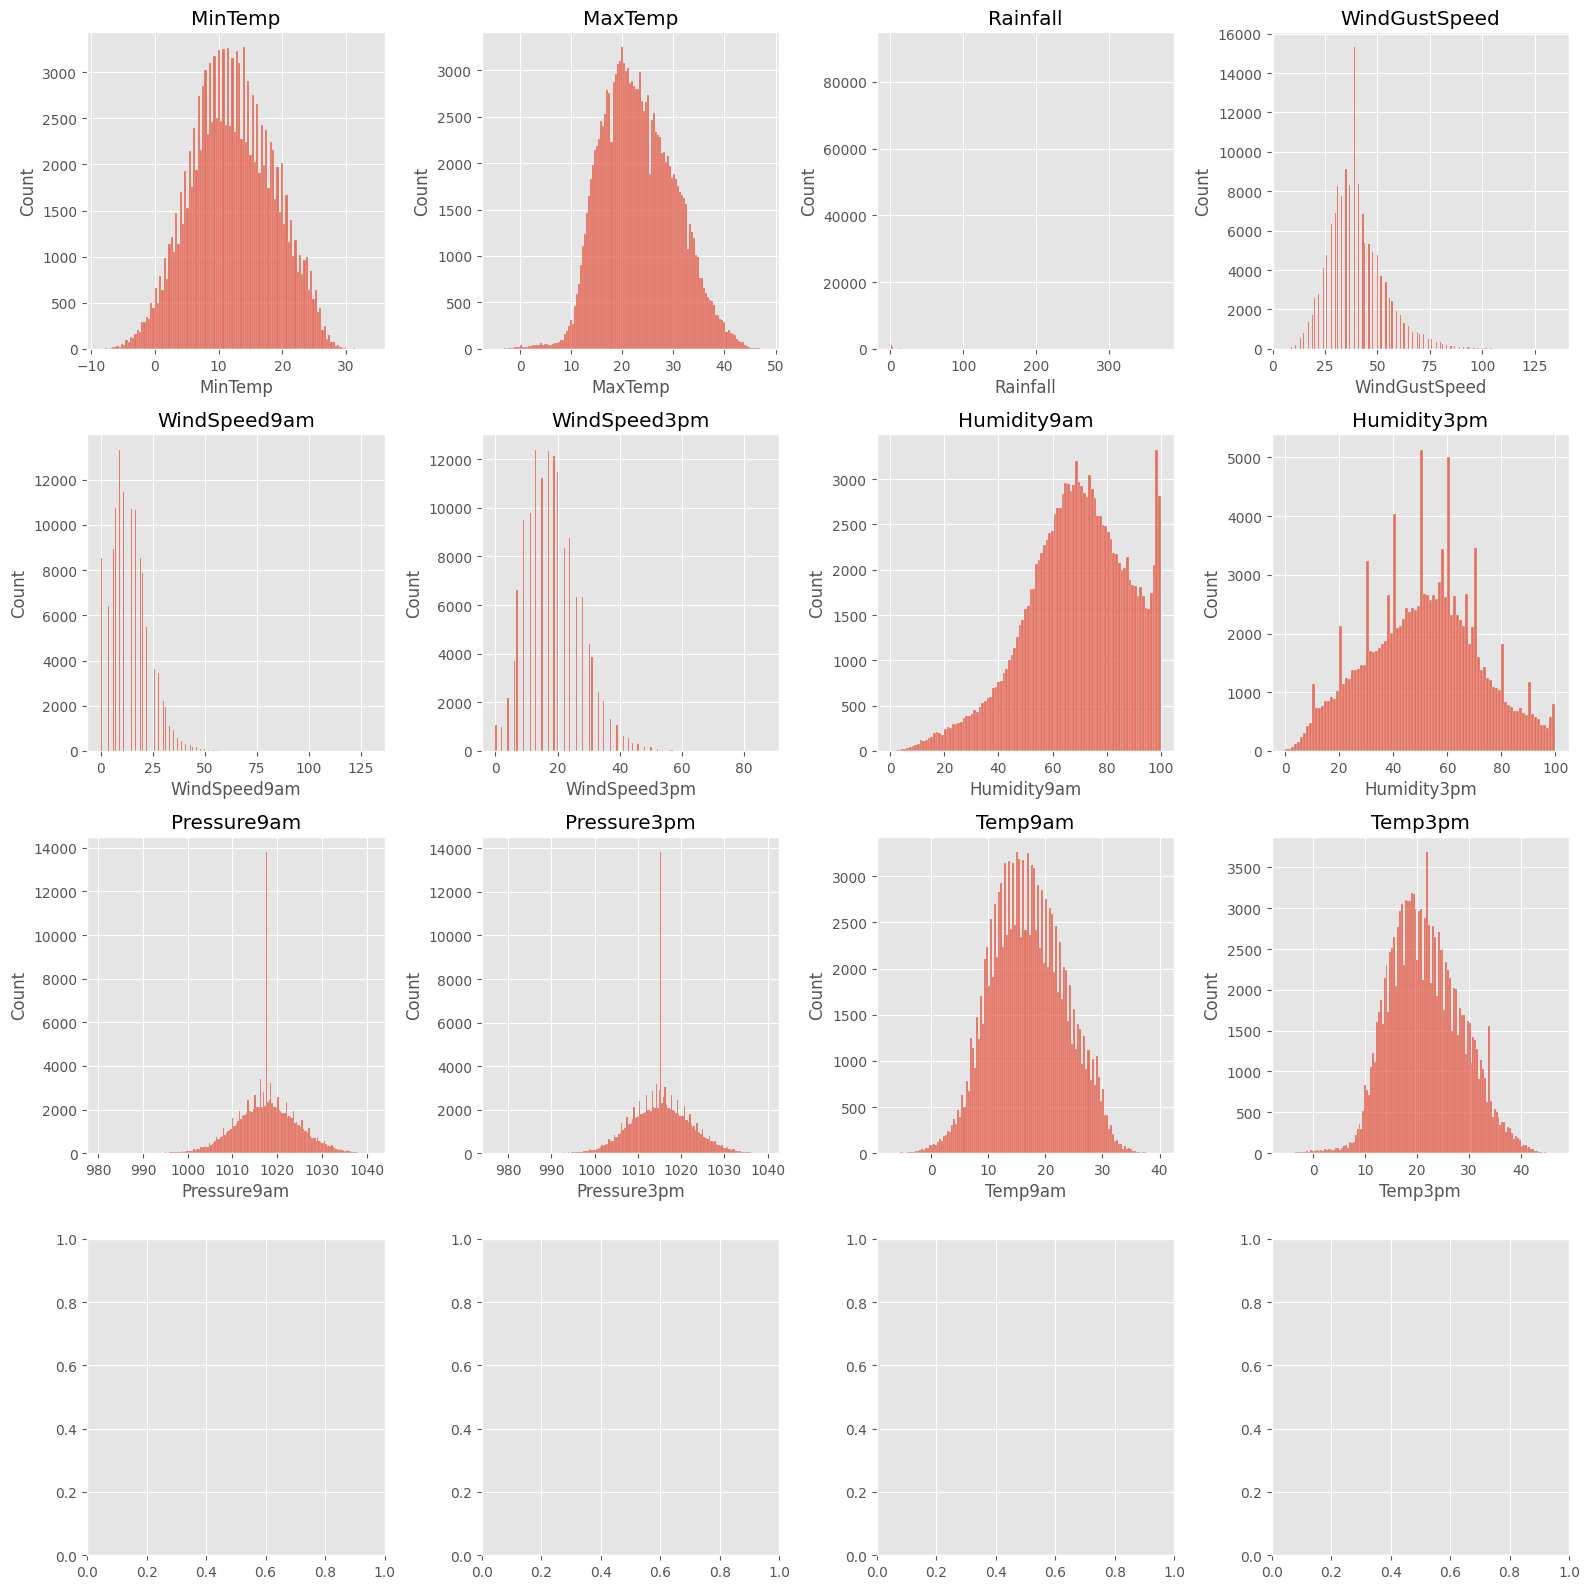

In [18]:
fig, ax = plt.subplots(3, 4, figsize=(16, 16))
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, ax=ax[i // 4, i % 4])
    ax[i // 4, i % 4].set_title(col)
plt.tight_layout()
plt.savefig('chart_all_columns.png')
plt.show()

### Average Maximum Temperature by Month

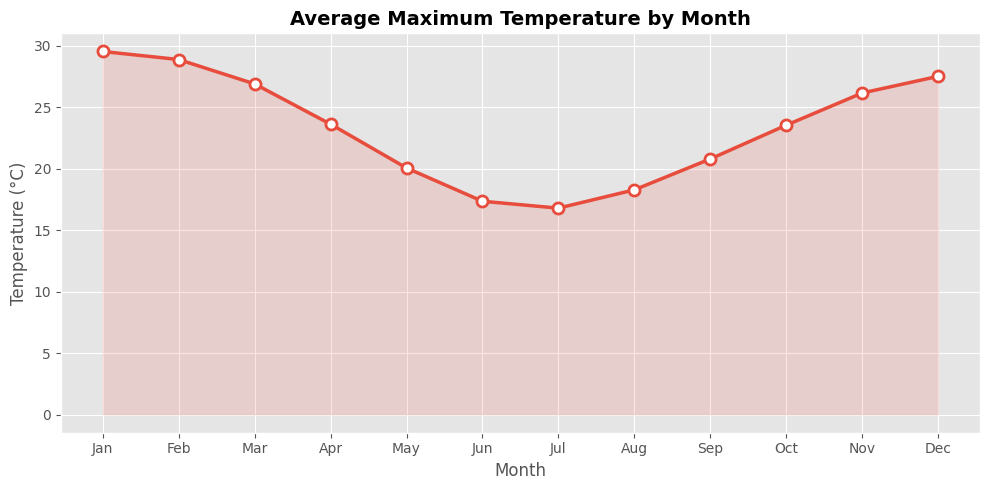

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
monthly_temp = df.groupby('Month')['MaxTemp'].mean()
ax.plot(monthly_temp.index, monthly_temp.values, marker='o', linewidth=2.5,
        color='#e74c3c', markerfacecolor='white', markeredgewidth=2, markersize=8)
ax.fill_between(monthly_temp.index, monthly_temp.values, alpha=0.15, color='#e74c3c')
ax.set_title('Average Maximum Temperature by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('chart_avg_maxtemp_month.png')
plt.show()

### Average Rainfall per Month

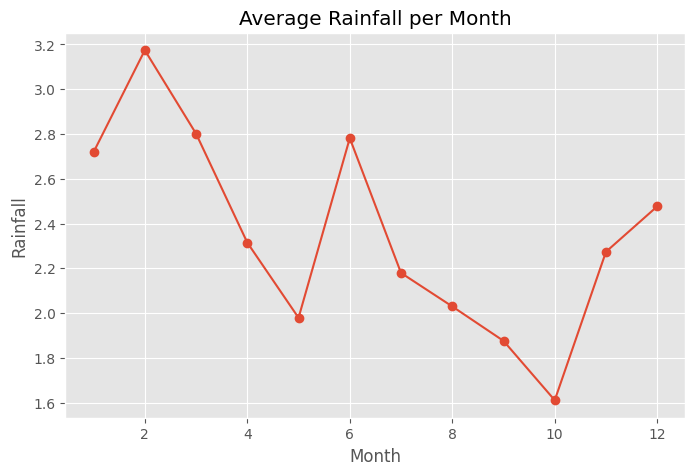

In [20]:
monthly_rain = df.groupby('Month')['Rainfall'].mean()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind='line', marker='o')
plt.title("Average Rainfall per Month")
plt.ylabel("Rainfall")
plt.savefig('chart_avg_rainfall_month.png')
plt.show()

### Rain Tomorrow ?

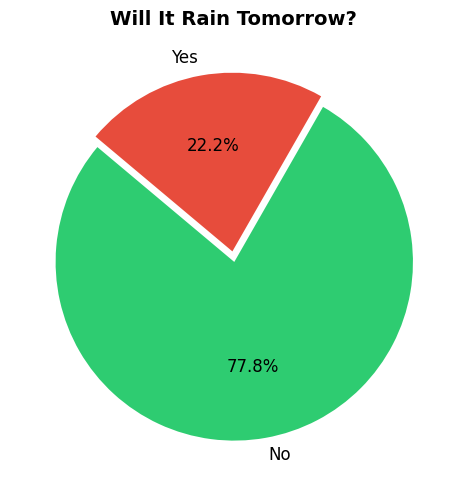

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
rain_counts = df['RainTomorrow'].value_counts()
wedges, texts, autotexts = ax.pie(rain_counts, labels=rain_counts.index,
                                   autopct='%1.1f%%', startangle=140,
                                   colors=['#2ecc71', '#e74c3c'],
                                   explode=(0.03, 0.03), textprops={'fontsize': 12})
ax.set_title('Will It Rain Tomorrow?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_rain_tomorrow_pie.png')
plt.show()

### Correlation Heatmap

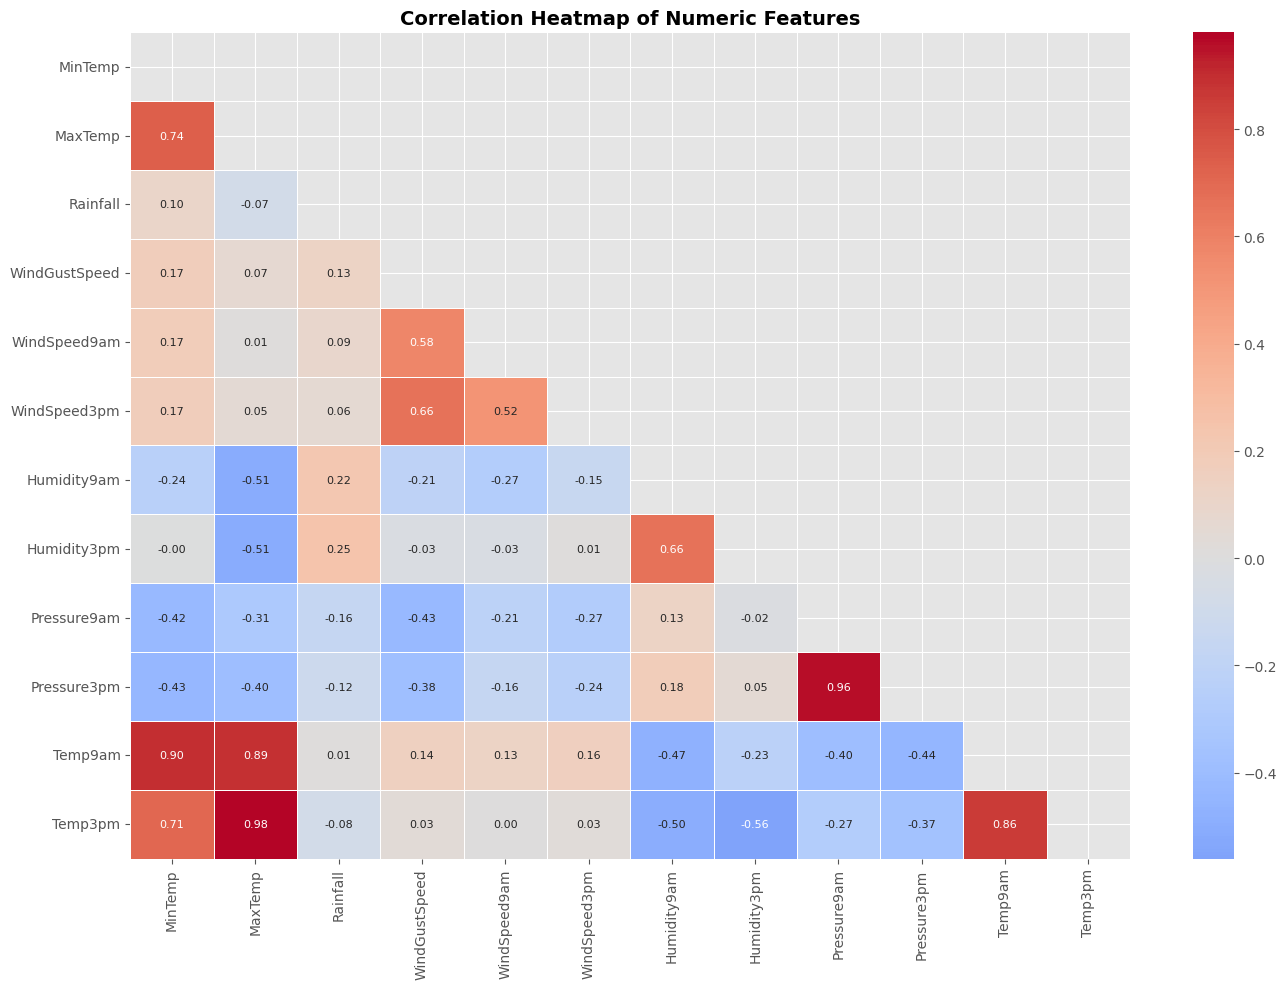

In [22]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png')
plt.show()

### Outlier Detection

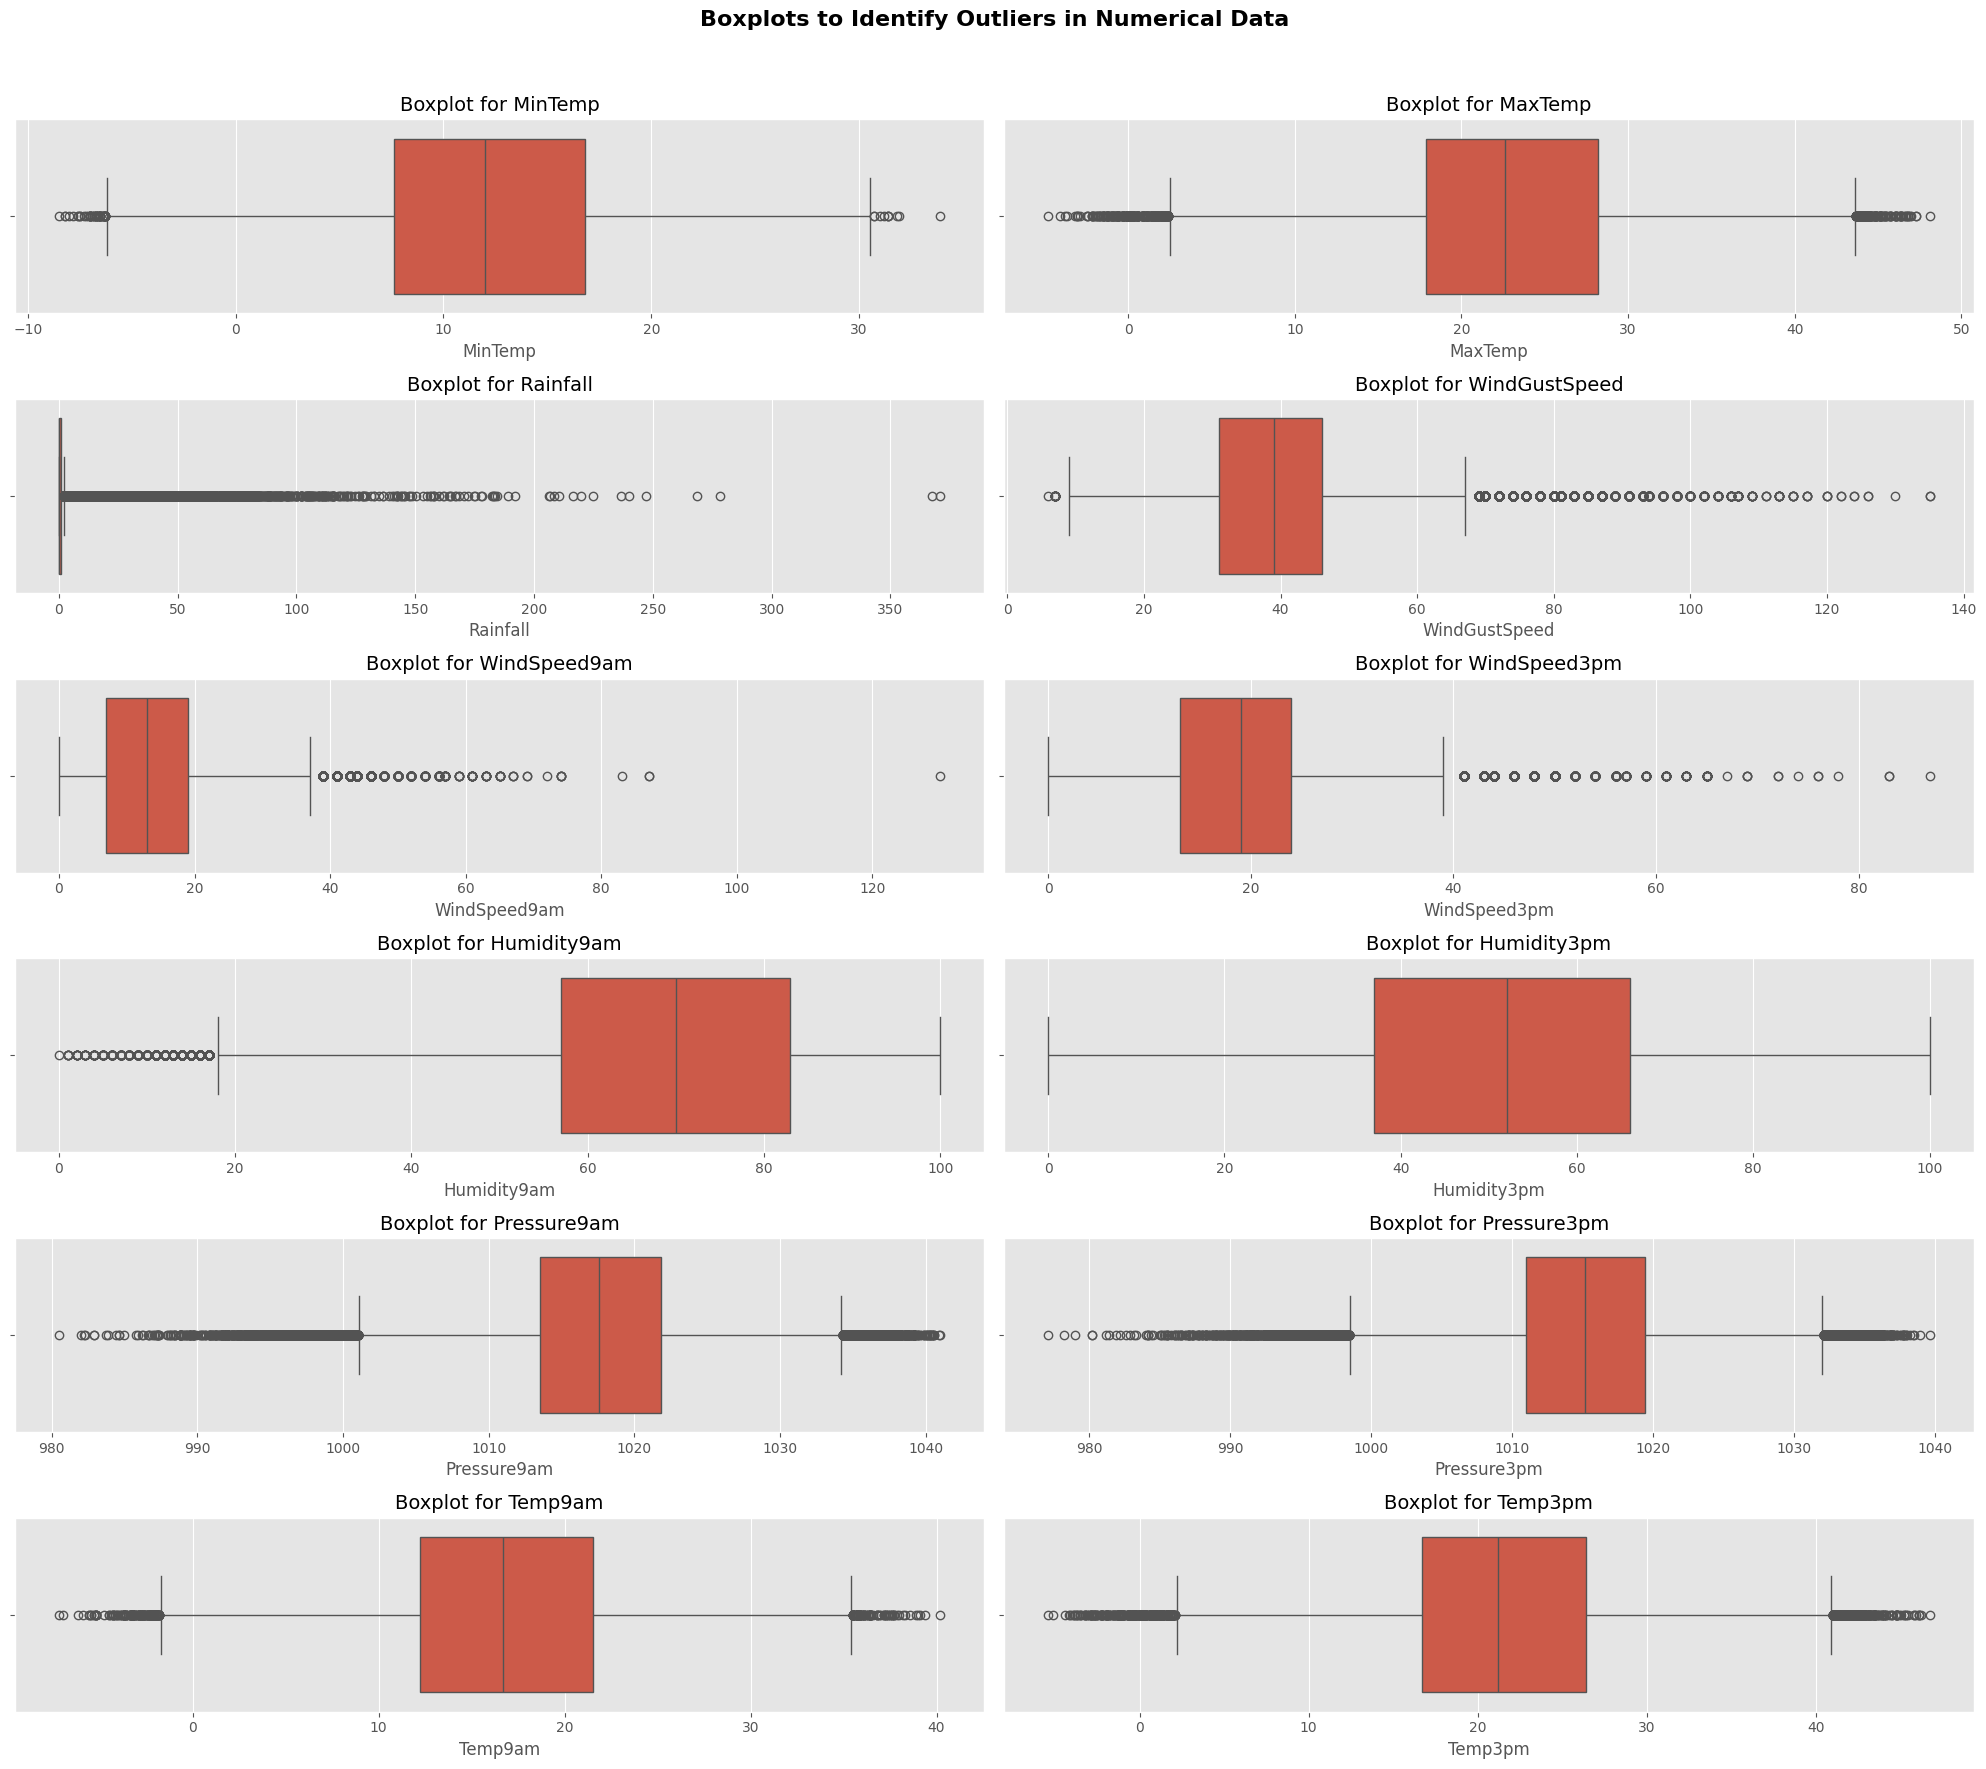

In [23]:
# Number of numerical columns
n = len(numeric_cols)  # fix: list has no .shape

# Number of rows for a 2-column grid
rows = math.ceil(n / 2)  # fix: correct row count for 2-column layout

# Set the figure size based on the number of rows
plt.figure(figsize=(20, rows * 3))  # fix: height based on rows, not n

# Create boxplots for each numerical column
for i, col in enumerate(numeric_cols, 1):  # fix: list has no .columns
    plt.subplot(rows, 2, i)  # fix: use rows
    sns.boxplot(data=df, x=col)  # fix: use df, not numeric_cols
    plt.title(f"Boxplot for {col}", fontsize=14)
    plt.xlabel(col, fontsize=12)

# Overall title for the entire figure
plt.suptitle("Boxplots to Identify Outliers in Numerical Data", fontsize=16, weight='bold')

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('chart_boxplots_outliers.png')
plt.show()

### Boxplot Outlier Analysis

**1. Log Transformation for Right-Skewed Variables**

Targets: Rainfall, WindGustSpeed, WindSpeed9am, WindSpeed3pm

These columns have a long right tail with extreme values. Log transformation compresses large values and pulls them closer to the bulk of the data.


In [ ]:
skewed_cols = ['Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

for col in skewed_cols:
    df[col + '_log'] = np.log1p(df[col])  # log1p handles 0 values safely (log(1+x))

**2. Investigate Suspicious Low-Pressure Records**

Targets: Pressure9am, Pressure3pm

Outliers sit around ~980 hPa, which is unusually low. These could be:

Legitimate storm/cyclone events → keep them
Sensor errors → remove or impute

If those low-pressure rows also show high rainfall and wind → legitimate, keep them.

In [24]:
# Inspect low pressure records
low_pressure = df[df['Pressure9am'] < 990]
print(low_pressure[['Date', 'Location', 'Pressure9am', 'Pressure3pm', 'Rainfall', 'WindGustSpeed']])

             Date          Location  Pressure9am  Pressure3pm  Rainfall  \
683    2010-10-15            Albury        989.8        982.9      22.2   
21310  2009-07-11     NorfolkIsland        980.5        979.0      34.4   
30472  2008-11-23            Sydney        986.7        991.0       0.2   
45975  2008-11-23          Canberra        987.4        993.9      13.8   
57872  2016-09-29          Ballarat        989.4        987.3      13.0   
58154  2008-12-13           Bendigo        989.5        994.6      30.4   
63921  2016-09-29              Sale        989.3        989.4       0.0   
66930  2016-09-29  MelbourneAirport        989.7        988.2       4.4   
67365  2008-12-13         Melbourne        988.9        993.6      36.2   
70123  2016-09-29         Melbourne        989.5        988.3       1.8   
74710  2016-09-29              Nhil        986.9        982.6      11.0   
75265  2009-10-13          Portland        989.5        990.4       9.6   
77719  2016-09-29        

Low-pressure rows: 73
Low-pressure + high rainfall + high wind rows: 5
             Date       Location  Pressure9am  Pressure3pm  Rainfall  \
21310  2009-07-11  NorfolkIsland        980.5        979.0      34.4   
130291 2009-09-27         Hobart        988.3        999.0      32.4   
131667 2013-10-01         Hobart        988.9        993.0      31.2   
129437 2016-05-21        Walpole        989.0        992.8      27.4   
105292 2016-09-29      Nuriootpa        982.0        986.4      23.9   

        WindGustSpeed  
21310            81.0  
130291           83.0  
131667           81.0  
129437           81.0  
105292           83.0  


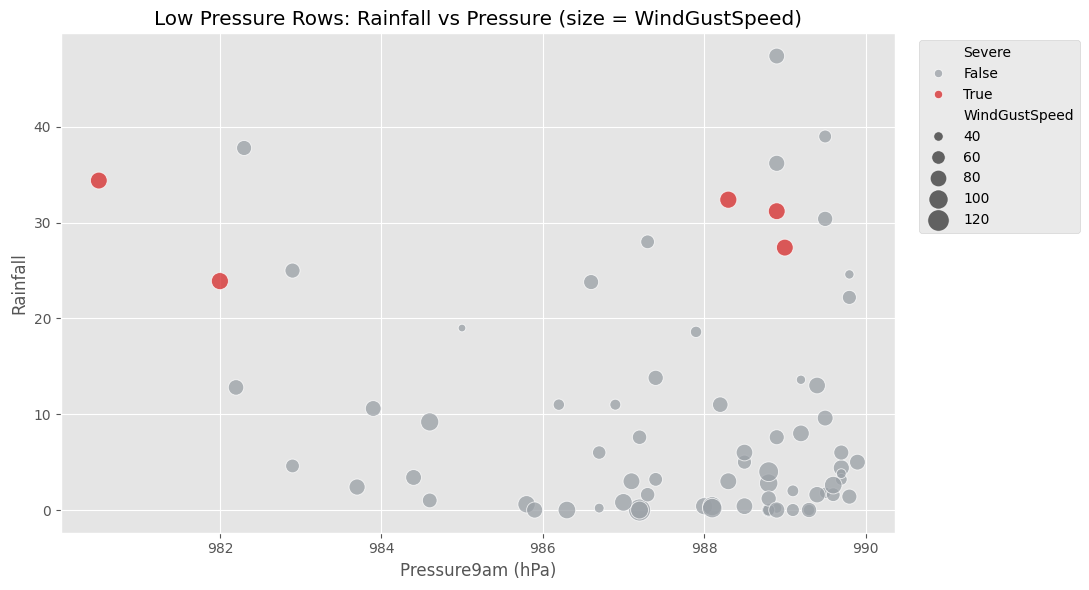

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Base filter: low pressure
low_pressure = df[df["Pressure9am"] < 990].copy()

# 2) Define "high" rainfall and wind using quantiles inside low-pressure subset
rain_thr = low_pressure["Rainfall"].quantile(0.75)
wind_thr = low_pressure["WindGustSpeed"].quantile(0.75)

# 3) Keep rows that are both high rainfall and high wind
severe_low_pressure = low_pressure[
    (low_pressure["Rainfall"] >= rain_thr) &
    (low_pressure["WindGustSpeed"] >= wind_thr)
].copy()

print("Low-pressure rows:", len(low_pressure))
print("Low-pressure + high rainfall + high wind rows:", len(severe_low_pressure))
print(severe_low_pressure[["Date", "Location", "Pressure9am", "Pressure3pm", "Rainfall", "WindGustSpeed"]]
      .sort_values(["Rainfall", "WindGustSpeed"], ascending=False)
      .head(20))

# 4) Chart: pressure vs rainfall, color by severe condition, point size by wind
plot_df = low_pressure.copy()
plot_df["Severe"] = (
    (plot_df["Rainfall"] >= rain_thr) &
    (plot_df["WindGustSpeed"] >= wind_thr)
)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=plot_df,
    x="Pressure9am",
    y="Rainfall",
    hue="Severe",
    size="WindGustSpeed",
    sizes=(30, 250),
    alpha=0.75,
    palette={False: "#9aa0a6", True: "#d62728"}
)
plt.title("Low Pressure Rows: Rainfall vs Pressure (size = WindGustSpeed)")
plt.xlabel("Pressure9am (hPa)")
plt.ylabel("Rainfall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**3. Check Near-Zero Humidity Values**

Target: Humidity9am

Values near 0% humidity are physically possible in deserts but rare in most climates. Verify they are not data entry errors.

If they appear in unrealistic locations/temperatures → replace with NaN and impute.

In [ ]:
# Check suspicious very low humidity
low_humidity = df[df['Humidity9am'] < 5]
print(low_humidity[['Date', 'Location', 'Humidity9am', 'Humidity3pm', 'MaxTemp']])

# Check percentage of affected rows
print(f"Affected rows: {len(low_humidity)} ({len(low_humidity)/len(df)*100:.2f}%)")

             Date      Location  Humidity9am  Humidity3pm  MaxTemp
15731  2010-09-17     Newcastle          3.0         32.0     19.8
102939 2010-01-22     Nuriootpa          3.0         39.0     37.9
105816 2009-09-12       Woomera          2.0          3.0     37.2
106931 2012-10-31       Woomera          3.0         25.0     38.0
106965 2013-01-04       Woomera          4.0          1.0     46.1
107199 2013-09-23       Woomera          4.0         11.0     31.1
107225 2013-10-19       Woomera          4.0         25.0     33.0
107226 2013-10-20       Woomera          0.0          0.0     40.0
107239 2013-11-02       Woomera          3.0          3.0     37.6
107244 2013-11-07       Woomera          2.0         10.0     36.4
107268 2013-12-01       Woomera          4.0          6.0     37.5
107299 2014-01-01       Woomera          3.0          1.0     46.8
107615 2014-11-13       Woomera          2.0          0.0     41.6
107985 2015-11-18       Woomera          4.0          3.0     

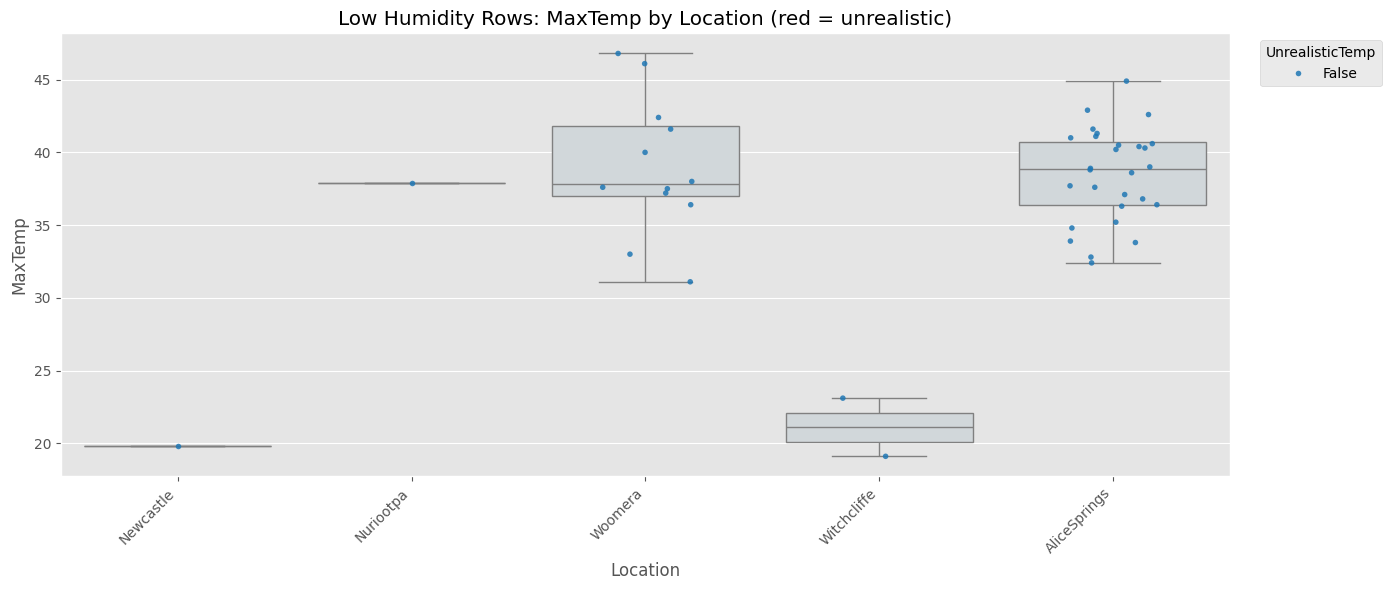

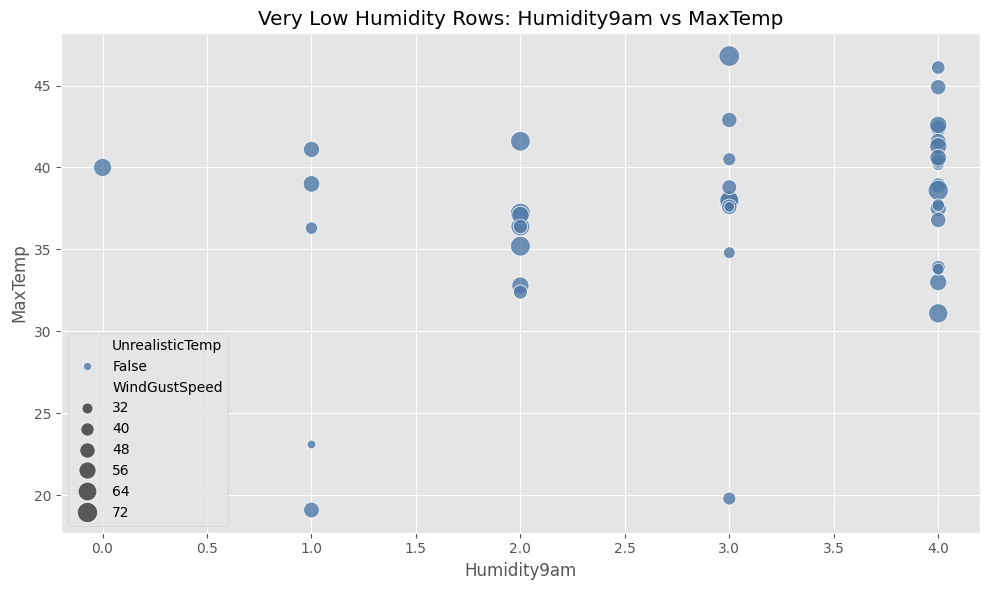

Flagged unrealistic rows: 0
Empty DataFrame
Columns: [Date, Location, Humidity9am, Humidity3pm, MaxTemp]
Index: []


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Filter suspicious very low humidity
low_humidity = df[df["Humidity9am"] < 5].copy()

# Quick stats
print(low_humidity[["Date", "Location", "Humidity9am", "Humidity3pm", "MaxTemp"]].head(20))
print(f"Affected rows: {len(low_humidity)} ({len(low_humidity)/len(df)*100:.2f}%)")

# 2) Define "unrealistic" MaxTemp within each location using robust IQR rule
# For each location: flag if MaxTemp is outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
stats = low_humidity.groupby("Location")["MaxTemp"].agg(
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75)
)
stats["iqr"] = stats["q3"] - stats["q1"]
stats["low"] = stats["q1"] - 1.5 * stats["iqr"]
stats["high"] = stats["q3"] + 1.5 * stats["iqr"]

low_humidity = low_humidity.join(stats[["low", "high"]], on="Location")
low_humidity["UnrealisticTemp"] = (
    (low_humidity["MaxTemp"] < low_humidity["low"]) |
    (low_humidity["MaxTemp"] > low_humidity["high"])
)

# 3) Chart A: Distribution by location with flagged points
top_locs = low_humidity["Location"].value_counts().head(15).index
plot_a = low_humidity[low_humidity["Location"].isin(top_locs)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_a, x="Location", y="MaxTemp", color="#cfd8dc", showfliers=False)
sns.stripplot(
    data=plot_a,
    x="Location",
    y="MaxTemp",
    hue="UnrealisticTemp",
    palette={False: "#1f77b4", True: "#d62728"},
    alpha=0.85,
    jitter=0.2,
    size=4
)
plt.xticks(rotation=45, ha="right")
plt.title("Low Humidity Rows: MaxTemp by Location (red = unrealistic)")
plt.xlabel("Location")
plt.ylabel("MaxTemp")
plt.legend(title="UnrealisticTemp", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4) Chart B: Humidity vs MaxTemp, flagged and labeled by location
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=low_humidity,
    x="Humidity9am",
    y="MaxTemp",
    hue="UnrealisticTemp",
    style="UnrealisticTemp",
    size="WindGustSpeed" if "WindGustSpeed" in low_humidity.columns else None,
    sizes=(40, 220),
    palette={False: "#4e79a7", True: "#e15759"},
    alpha=0.8
)
plt.title("Very Low Humidity Rows: Humidity9am vs MaxTemp")
plt.xlabel("Humidity9am")
plt.ylabel("MaxTemp")
plt.tight_layout()
plt.show()

# 5) Table of flagged rows for review
flagged = low_humidity[low_humidity["UnrealisticTemp"]].copy()
print("Flagged unrealistic rows:", len(flagged))
print(
    flagged[["Date", "Location", "Humidity9am", "Humidity3pm", "MaxTemp"]]
    .sort_values(["Location", "MaxTemp"])
    .head(50)
)

**4. IQR-Based Capping (Winsorization) Before ML**

Targets: All variables with outliers

Rather than removing rows (which loses data), cap extreme values at the 1st and 99th percentiles. This preserves row count while limiting outlier influence on models.

In [ ]:
from scipy.stats.mstats import winsorize

cols_to_winsorize = [
    'Rainfall', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am'
]

for col in cols_to_winsorize:
    df[col + '_winsorized'] = winsorize(df[col], limits=[0.01, 0.01])
    # limits=[0.01, 0.01] caps bottom 1% and top 1%

## Results

- Columns inutiles : Date